# Dataset Creation

## Setup

In [1]:
from openai import OpenAI
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.metrics.pairwise import cosine_distances
import uuid
import json
from pathlib import Path
from utils import BASE_DIR, INPUT_DIR, PROMPTS_DIR, OUTPUTS_DIR, API_INPUT_DIR, API_OUTPUT_DIR, API_JOBS_DIR, create_prompt, create_batch_input_file, \
    send_input_to_api, wait_for_batch_completion, retrieve_api_output, output_jsonl_to_dataframe, run_whole_batch_process

API_KEY = os.getenv("OPENAI_API_KEY_UNIVERSITY")
client = OpenAI(api_key=API_KEY)

## Helper Functions

In [2]:
def load_df(file_name: str, file_dir: Path=INPUT_DIR) -> pd.DataFrame:
    file_path = file_dir / file_name
    if file_path.suffix == ".pkl":
        return pd.read_pickle(file_path)
    elif file_path.suffix == ".xlsx":
        return pd.read_excel(file_path)
    elif file_path.suffix == ".csv":
        return pd.read_csv(file_path)
    else:
        raise ValueError("Unsupported file format")
    
def merge_dfs(df1: pd.DataFrame, df2: pd.DataFrame, on_left: str="id", on_right="custom_id", how: str="left", df1_columns=None, df2_columns=None) -> pd.DataFrame:
    if df1_columns is not None:
        df1 = df1[df1_columns + [on_left]]
    if df2_columns is not None:
        df2 = df2[df2_columns + [on_right]]
    merged_df = pd.merge(df1, df2, left_on=on_left, right_on=on_right, how=how, suffixes=('_left', '_right'))
    return merged_df

### Taxonomy

In [3]:
def flatten_taxonomy(tax, level0=None, level1=None):
    rows = []
    if isinstance(tax, dict):
        for k, v in tax.items():
            if level0 is None:
                rows += flatten_taxonomy(v, level0=k, level1=None)
            elif level1 is None:
                rows += flatten_taxonomy(v, level0=level0, level1=k)
            else:
                rows += flatten_taxonomy(v, level0=level0, level1=level1)
    elif isinstance(tax, (list, tuple, set)):
        for item in tax:
            rows.append({"Level0": level0, "Level1": level1, "Label": item})
    else:
        rows.append({"Level0": level0, "Level1": level1, "Label": tax})
    return rows

## Run Batching

In [4]:
df_questions = load_df("likely_memorized_ds_questions.xlsx")

### Create Absolute Solutions

In [7]:
# df_solutions = run_whole_batch_process("absolute_solution_memorized_dataset", "solve_absolute_solution", df_questions, "question_english", model="gpt-5.2-2025-12-11")
df_solutions = output_jsonl_to_dataframe("absolute_solution_memorized_dataset_output")
df_questions['id'] = df_questions['id'].astype(str)
df_solutions['custom_id'] = df_solutions['custom_id'].astype(str)
df_questions = merge_dfs(df_questions, df_solutions, on_left="id", on_right="custom_id", how="left", df2_columns=["answer_text"]).rename(columns={"answer_text": "solution_english"}).drop(columns=["custom_id"])
df_with_labels = df_questions
df_questions.to_excel(INPUT_DIR / "likely_memorized_ds_questions_with_absolute_solutions.xlsx", index=False)

### Solving Questions

In [8]:
# duplicate each row in df_with_labels n times, add a column 'duplicate_id' with values 0, 1, ..., n-1
n = 7
# repeat each row n times
df_dup = df_with_labels.loc[df_with_labels.index.repeat(n)].copy()

# add duplicate_id: 0,1,2 for each original row
df_dup["duplicate_id"] = df_dup.groupby(level=0).cumcount()

# create rep_id = id + "_" + duplicate_id
df_dup["rep_id"] = df_dup["id"].astype(str) + "_" + df_dup["duplicate_id"].astype(str)

# (optional) reset index if you want a clean sequential index
df_dup = df_dup.reset_index(drop=True)


In [9]:
df_solutions = run_whole_batch_process("solve_problem_o3", "solve_suffix", df_dup, "question_english", id_column="rep_id", model="o3")

Sending batch input file to API: c:\projects\LLMsForEducation\batch_files\input\solve_problem_o3_input.jsonl
✅ Job created: batch_6984fafb85cc8190bb88a265e3976b10
   Info saved to: c:\projects\LLMsForEducation\batch_files\job\solve_problem_o3_job.json
Batch job batch_6984fafb85cc8190bb88a265e3976b10 status: validating. Checking again in 30 seconds...
Batch job batch_6984fafb85cc8190bb88a265e3976b10 status: in_progress. Checking again in 30 seconds...
Batch job batch_6984fafb85cc8190bb88a265e3976b10 status: in_progress. Checking again in 30 seconds...
Batch job batch_6984fafb85cc8190bb88a265e3976b10 status: in_progress. Checking again in 30 seconds...
Batch job batch_6984fafb85cc8190bb88a265e3976b10 status: in_progress. Checking again in 30 seconds...
Batch job batch_6984fafb85cc8190bb88a265e3976b10 status: in_progress. Checking again in 30 seconds...
Batch job batch_6984fafb85cc8190bb88a265e3976b10 status: in_progress. Checking again in 30 seconds...
Batch job batch_6984fafb85cc8190bb8

In [12]:
# df_solutions = output_jsonl_to_dataframe("solve_problem_o3_output")
df_with_solutions = merge_dfs(df_dup, df_solutions, on_left="rep_id", on_right="custom_id", how="left", df2_columns=["answer_text"]).rename(columns={
    "answer_text": "model_solution"}).drop(columns=['custom_id'])
df_with_solutions.head()


,id,question_english,source,solution_english,duplicate_id,rep_id,model_solution
0,1,Prove an upper bound on the height of an AVL t...,michal and amir,"Let \(T\) be an AVL tree. For a node \(v\), wr...",0,1_0,Let N(h) be the minimum number of keys in an A...
1,1,Prove an upper bound on the height of an AVL t...,michal and amir,"Let \(T\) be an AVL tree. For a node \(v\), wr...",1,1_1,Let N(h) be the minimum number of nodes in an ...
2,1,Prove an upper bound on the height of an AVL t...,michal and amir,"Let \(T\) be an AVL tree. For a node \(v\), wr...",2,1_2,Let N(h) be the minimum number of internal nod...
3,1,Prove an upper bound on the height of an AVL t...,michal and amir,"Let \(T\) be an AVL tree. For a node \(v\), wr...",3,1_3,Let N(h) be the minimum number of keys that an...
4,1,Prove an upper bound on the height of an AVL t...,michal and amir,"Let \(T\) be an AVL tree. For a node \(v\), wr...",4,1_4,Let N(h) be the minimum number of nodes in an ...


### Grading

In [13]:
df_with_solutions['answer_grading_suffix'] = 'student answer:\n' + df_with_solutions['model_solution'] + '\ntrue solution:\n' + df_with_solutions['solution_english']
df_grades = run_whole_batch_process("grade_answer_o3", "grader", df_with_solutions, "answer_grading_suffix", id_column="rep_id")

Sending batch input file to API: c:\projects\LLMsForEducation\batch_files\input\grade_answer_o3_input.jsonl
✅ Job created: batch_698500720fd48190af37435d4b570f90
   Info saved to: c:\projects\LLMsForEducation\batch_files\job\grade_answer_o3_job.json
Batch job batch_698500720fd48190af37435d4b570f90 status: validating. Checking again in 30 seconds...
Batch job batch_698500720fd48190af37435d4b570f90 status: validating. Checking again in 30 seconds...
Batch job batch_698500720fd48190af37435d4b570f90 status: validating. Checking again in 30 seconds...
Batch job batch_698500720fd48190af37435d4b570f90 status: in_progress. Checking again in 30 seconds...
Batch job batch_698500720fd48190af37435d4b570f90 status: in_progress. Checking again in 30 seconds...
Batch job batch_698500720fd48190af37435d4b570f90 status: in_progress. Checking again in 30 seconds...
Batch job batch_698500720fd48190af37435d4b570f90 status: in_progress. Checking again in 30 seconds...
Batch job batch_698500720fd48190af37435

In [19]:
# df_with_solutions = df_with_solutions.drop(columns=['answer_grading_suffix'])
final_df_dup = merge_dfs(df_with_solutions, df_grades, on_left="rep_id", on_right="custom_id", how="left", df2_columns=["answer_text", "reasoning_tokens", "total_tokens", "completion_tokens"]).rename(columns={"answer_text": "answer_grade"}).drop(columns=['custom_id'])
final_df_dup['grade'] = final_df_dup['answer_grade'].str.extract(r'Grade:\s*(\w+)')
final_df_dup.head()
final_df_dup.to_excel(INPUT_DIR / "likely_memorized_ds_with_model_solutions_and_grades.xlsx", index=False)  

### Solution Embedding

In [20]:
def preprocess_answer(text):
    if not isinstance(text, str):
        return ""
    return text.strip()

def embed_texts_in_batches(client, texts, model="text-embedding-3-large", max_batch_chars=200_000):
    """
    Batches embedding requests to avoid max tokens/request errors.
    Uses a conservative character budget (approx proxy for tokens).
    Returns a list of embedding vectors aligned with `texts`.
    """
    embeddings = [None] * len(texts)

    batch_idxs = []
    batch_texts = []
    cur_chars = 0

    def flush():
        nonlocal batch_idxs, batch_texts, cur_chars
        if not batch_texts:
            return

        resp = client.embeddings.create(model=model, input=batch_texts)
        # resp.data is in the same order as input
        for i, item in enumerate(resp.data):
            embeddings[batch_idxs[i]] = item.embedding

        batch_idxs = []
        batch_texts = []
        cur_chars = 0

    for i, t in enumerate(texts):
        t = t or ""
        # avoid sending pure empty strings (still keep alignment)
        # (embedding an empty string is allowed, but sometimes not useful)
        # We'll keep it but it's tiny anyway.
        t_chars = len(t)

        # If a single text is huge, still send it alone.
        if batch_texts and (cur_chars + t_chars > max_batch_chars):
            flush()

        batch_idxs.append(i)
        batch_texts.append(t)
        cur_chars += t_chars

    flush()
    return embeddings

embedding_model = "text-embedding-3-large"

texts = final_df_dup["model_solution"].apply(preprocess_answer).tolist()

embeddings = embed_texts_in_batches(
    client=client,
    texts=texts,
    model=embedding_model,
    max_batch_chars=200_000,  # conservative; lower if you still hit limits
)

final_df_dup["embedding"] = embeddings

X = np.vstack(final_df_dup["embedding"].values)  # shape: (n_rows, 3072)


In [21]:
from sklearn.metrics.pairwise import cosine_distances

def avg_pairwise_distance(vectors):
    D = cosine_distances(vectors)
    n = len(vectors)
    return D[np.triu_indices(n, k=1)].mean()

avg_distances = (
    final_df_dup
    .groupby("id")["embedding"]
    .apply(lambda x: avg_pairwise_distance(np.vstack(x)))
    .reset_index(name="avg_answer_distance")
)

avg_distances.head()

,id,avg_answer_distance
0,1,0.067055
1,10,0.132953
2,11,0.058923
3,12,0.049586
4,13,0.124690


## Data Analysis

### Analyze Potential Memorization / Reasoning Columns

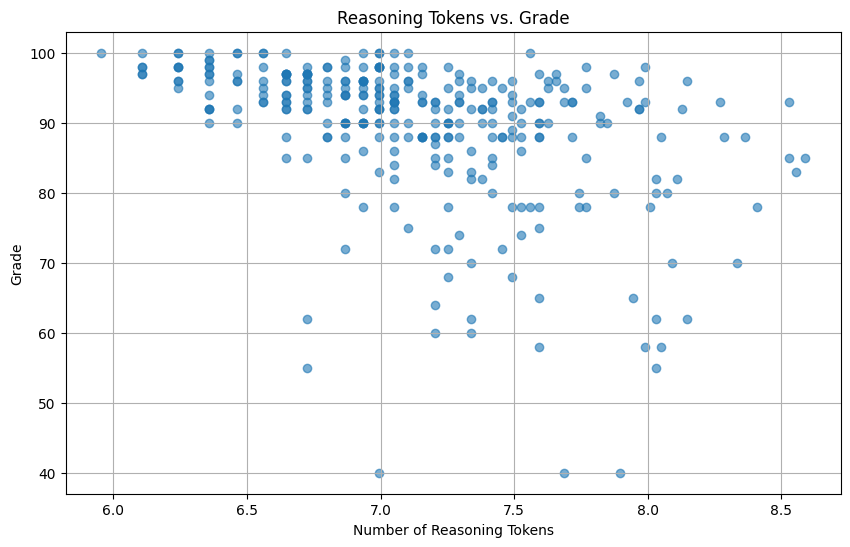

In [22]:
# draw a scatter plot of num of reasoning_tokens vs numeric grade in df_dup
# --- IGNORE ---
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
# don't map grades, use the numbers
# I said don't map
plt.scatter(np.log1p(final_df_dup['reasoning_tokens']), final_df_dup['grade'].astype(float), alpha=0.6)
plt.title('Reasoning Tokens vs. Grade')
# --- IGNORE ---
plt.xlabel('Number of Reasoning Tokens')
plt.ylabel('Grade')
plt.grid(True)
plt.show()


In [23]:
# group by df_dup by 'id' and extract for each id for reasoning tokens ad grade: the mean, the std, min and max values, median
# join the created columns back to df_with_labels on id
final_df_dup['grade'] = pd.to_numeric(final_df_dup['grade'], errors='coerce')
final_df_dup['log_reasoning_tokens'] = np.log1p(final_df_dup['reasoning_tokens'])
agg_funcs = {
    'reasoning_tokens': ['mean', 'std', 'min', 'max', 'median'],
    'log_reasoning_tokens': ['mean', 'std', 'min', 'max', 'median'],
    'grade': ['mean', 'std', 'min', 'max', 'median']
}
agg_df = final_df_dup.groupby('id').agg(agg_funcs)
agg_df.columns = ['_'.join(col).strip() for col in agg_df.columns.values]
# normalize agg_df created columns
for col in agg_df.columns:
    if 'reasoning_tokens' in col:
        agg_df[col+'_normalized'] = (agg_df[col] - agg_df[col].mean()) / agg_df[col].std()
    if 'grade' in col:
        agg_df[col+'_normalized'] = (agg_df[col] - agg_df[col].mean()) / agg_df[col].std()
final_df = df_with_labels.merge(agg_df, on='id', how='left').merge(avg_distances, on='id', how='left')
final_df['avg_answer_distance_normalized'] = (final_df['avg_answer_distance'] - final_df['avg_answer_distance'].mean()) / final_df['avg_answer_distance'].std()
final_df.head()

# final_df.to_excel(OUTPUTS_DIR / "final_exams_dataset_with_aggregations.xlsx", index=False)


,id,question_english,source,solution_english,reasoning_tokens_mean,reasoning_tokens_std,reasoning_tokens_min,reasoning_tokens_max,reasoning_tokens_median,log_reasoning_tokens_mean,...,log_reasoning_tokens_min_normalized,log_reasoning_tokens_max_normalized,log_reasoning_tokens_median_normalized,grade_mean_normalized,grade_std_normalized,grade_min_normalized,grade_max_normalized,grade_median_normalized,avg_answer_distance,avg_answer_distance_normalized
0,1,Prove an upper bound on the height of an AVL t...,michal and amir,"Let \(T\) be an AVL tree. For a node \(v\), wr...",2770.285714,895.019872,1472,4160,2624.0,7.878578,...,1.258321,1.551263,1.567742,-0.147334,1.061396,-0.767957,0.343687,0.072971,0.067055,-0.990516
1,2,Describe the different rotations used to rebal...,michal and amir,"In an AVL tree, rebalancing is performed by lo...",1170.285714,168.172247,896,1408,1152.0,7.056746,...,0.147588,-0.510565,-0.267113,-0.010632,-0.830397,0.506726,-0.343687,-0.291883,0.131666,0.666844
2,3,Analyze the time complexity of binary search a...,michal and amir,Let \(n\) be the length of the sorted list. Bi...,1042.285714,176.103865,832,1280,1024.0,6.938250,...,-0.018175,-0.691903,-0.529556,0.091894,-0.836447,0.506726,-0.343687,-0.048647,0.099363,-0.161759
3,4,Analyze the time complexity of the QuickSort a...,michal and amir,Let \(T(n)\) denote the running time of QuickS...,1490.285714,329.903882,1024,1984,1536.0,7.285848,...,0.446304,0.142020,0.374006,-0.215685,0.443389,-0.413879,0.000000,-0.048647,0.128439,0.584070
4,5,Prove the correctness of the QuickSort algorithm.,michal and amir,"Let `QUICKSORT(A, ℓ, r)` be the standard in-pl...",1965.714286,390.547357,1408,2560,2048.0,7.566759,...,1.158846,0.627127,1.015245,0.501998,-0.652266,0.648357,0.171844,0.559442,0.170237,1.656259


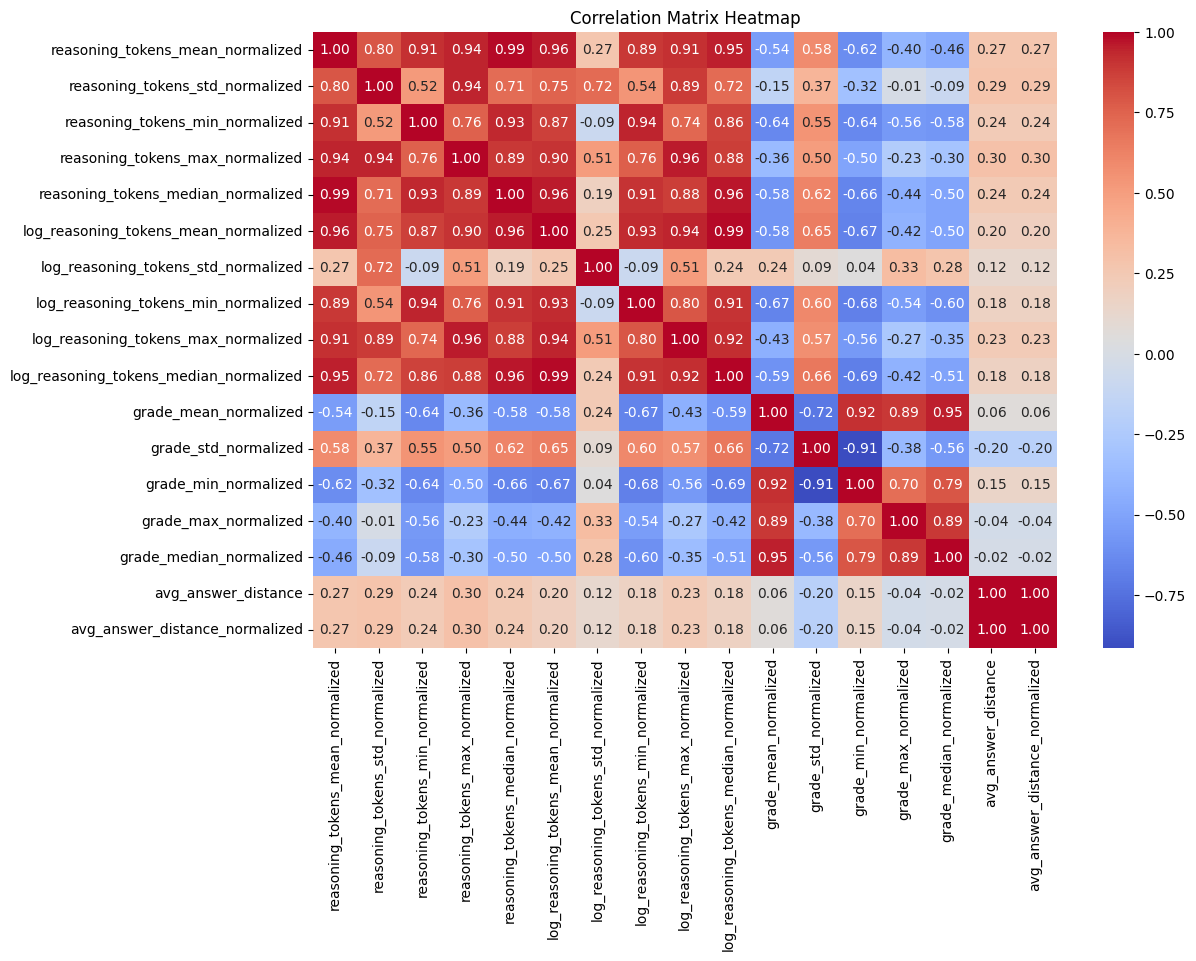

Plotting 1D scatter for column: reasoning_tokens_std_normalized


Plotting 1D scatter for column: grade_std_normalized


Plotting 1D scatter for column: log_reasoning_tokens_mean_normalized


Plotting 1D scatter for column: reasoning_tokens_mean


Plotting 1D scatter for column: grade_std


Plotting 1D scatter for column: log_reasoning_tokens_mean


Plotting 1D scatter for column: avg_answer_distance


Plotting 1D scatter for column: avg_answer_distance_normalized


In [24]:
final_df_filtered = final_df[final_df['reasoning_tokens_std_normalized'] < 0.3]
df_in_use = final_df.copy()

df_in_use['id'] = df_in_use['id'].astype(object)
agg_df['id'] = agg_df.index.astype(object)
# show correlation matrix heatmap of agg_df for all numeric columns - without id column and non normalized columns
numeric_cols = [col for col in df_in_use.select_dtypes(include=[np.number]).columns if 'normalized' in col or 'avg_answer_distance' in col]
corr_matrix = df_in_use[numeric_cols].corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix Heatmap')
plt.show()

# show one dimentional scatter plots for each of the following columns: 'reasoning_tokens_std_normalized', 'grade_std_normalized', 'log_reasoning_tokens_std_normalized'
cols = [
    "reasoning_tokens_std_normalized",
    "grade_std_normalized",
    "log_reasoning_tokens_mean_normalized",
    "reasoning_tokens_mean",
    "grade_std",
    "log_reasoning_tokens_mean",
    "avg_answer_distance",
    "avg_answer_distance_normalized"
]

for col in cols:
    print(f"Plotting 1D scatter for column: {col}")
    mean_col = col.replace("std", "mean")
    std_col = col.replace("mean", "std")
    color_col = mean_col if "std" in col else std_col

    df_plot = df_in_use.copy()
    df_plot["_y"] = 0  # keep it 1D

    fig = px.scatter(
        df_plot,
        x=col,
        y="_y",
        color=color_col,
        hover_data=["id", col, color_col],
        title=f"1D scatter: {col} (colored by {color_col})",
        color_continuous_scale="Viridis",
    )

    fig.update_yaxes(visible=False)
    fig.update_layout(
        xaxis_title=col,
        yaxis_title="",
        showlegend=False,
    )

    fig.show()

In [25]:
# show percentage table of 'avg_answer_distance', 'mean_grade', 'std_grade', 'mean_reasoning_tokens', 'std_reasoning_tokens' columns in final_df
# present it as a table without changing final_df
percentage_table = final_df[[
    'avg_answer_distance',
    'reasoning_tokens_mean',
    'reasoning_tokens_std',
    'grade_mean',
    'grade_std'
]].describe().loc[['mean', 'std', 'min', '25%', '50%', '75%', 'max']]
display(percentage_table)

,avg_answer_distance,reasoning_tokens_mean,reasoning_tokens_std,grade_mean,grade_std
mean,0.105669,1459.606349,403.194525,89.374603,5.371730
std,0.038984,736.347500,300.643810,8.360239,4.193064
min,0.040979,557.714286,71.212626,54.571429,0.786796
25%,0.077499,932.571429,195.023808,87.571429,1.976047
50%,0.104974,1243.428571,329.312126,91.142857,4.685337
75%,0.132953,1865.142857,426.819020,93.857143,7.197883
max,0.201663,4041.142857,1442.892333,99.285714,16.028249


In [26]:
final_df.to_excel(OUTPUTS_DIR / "likely_memorized_df.xlsx", index=False)

Go through examples manually
#### Determine "Memorization Suspicion Level" and classify accordingly

### Next - Extract Labels and Perform XGBoost